Importações e Carregamento dos Dados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Carregar o dataset processado (da camada Silver)
try:
    df = pd.read_csv('lancamentos-comerciais-processed.csv', sep=';')
    print("Dados processados carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Arquivo 'lancamentos-comerciais-processed.csv' não encontrado. Execute o notebook 'etl.ipynb' primeiro.")
    df = None

if df is not None:
    # Garante que a coluna de data está no formato correto
    df['data_lancamento'] = pd.to_datetime(df['data_lancamento'])
    display(df.head())

Dados processados carregados com sucesso!


<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\.'
<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\.'
C:\Users\alvea\AppData\Local\Temp\ipykernel_26300\4126725948.py:21: SyntaxWarning: invalid escape sequence '\$'
  df['RENDA_TOTAL'] = df['RENDA_TOTAL'].str.replace('R\$ ', '', regex=True)
C:\Users\alvea\AppData\Local\Temp\ipykernel_26300\4126725948.py:22: SyntaxWarning: invalid escape sequence '\.'
  df['RENDA_TOTAL'] = df['RENDA_TOTAL'].str.replace('\.', '', regex=True)
C:\Users\alvea\AppData\Local\Temp\ipykernel_26300\4126725948.py:17: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DATA_LANCAMENTO_OBRA'] = pd.to_datetime(df['DATA_LANCAMENTO_OBRA'], errors='coerce')


,DATA_LANCAMENTO_OBRA,TITULO_ORIGINAL,CPB_ROE,TIPO_OBRA,PAIS_OBRA,PUBLICO_TOTAL,RENDA_TOTAL,RAZAO_SOCIAL_DISTRIBUIDORA,REGISTRO_DISTRIBUIDORA,CNPJ_DISTRIBUIDORA
0,2025-07-31,ALDO BALDIN - UMA VIDA PELA MÚSICA,B2400467800000,DOCUMENTÁRIO,BRASIL,15,396.34,BRETZ FILMES DISTRIBUIDORA E PRODUTORA LTDA - EPP,19243.0,39.079.678/0001-47
1,2025-07-31,DEATH OF A UNICORN,E2500223800000,FICÇÃO,ESTADOS UNIDOS,245,5725.40,WARNER BROS. (SOUTH) INC.,265.0,33.015.827/0001-28
2,2025-07-31,GUNS UP,E2500153200000,FICÇÃO,ESTADOS UNIDOS,994,18646.57,DIAMOND FILMS DO BRASIL PRODUÇÃO E DISTRIBUIÇÃ...,22724.0,17.095.184/0001-13
3,2025-07-31,MATERIALISTS,E2500150300000,FICÇÃO,ESTADOS UNIDOS,37310,851099.53,COLUMBIA TRISTAR FILMES DO BRASIL LTDA,84.0,00.979.601/0001-98
4,2025-07-31,NADA,B2300179900000,FICÇÃO,BRASIL,238,311.31,EMBAUBA FILMES LTDA,23638.0,15.144.532/0001-70


Top 10 Distribuidoras por Faturamento


Top 10 Distribuidoras por Faturamento Total:


RAZAO_SOCIAL_DISTRIBUIDORA
THE WALT DISNEY COMPANY (BRASIL) LTDA.                               R$ 7,264,320,989.08
WARNER BROS. (SOUTH) INC.                                            R$ 6,313,124,097.16
COLUMBIA TRISTAR FILMES DO BRASIL LTDA                               R$ 4,417,065,268.77
FOX FILM DO BRASIL LTDA                                              R$ 3,024,833,597.63
PARAMOUNT PICTURES BRASIL DISTRIBUIDORA DE FILMES LTDA               R$ 2,762,324,842.15
SM DISTRIBUIDORA DE FILMES LTDA                                      R$ 2,720,058,164.26
FREESPIRIT DISTRIBUIDORA DE FILMES LTDA.                             R$ 1,151,480,984.75
UNIVERSAL PICTURES INTERNATIONAL BRAZIL LTDA.                        R$ 1,080,038,153.09
WMIX DISTRIBUIDORA LTDA.                                             R$ 1,059,518,504.97
DIAMOND FILMS DO BRASIL PRODUÇÃO E DISTRIBUIÇÃO AUDIOVISUAL LTDA.      R$ 446,334,484.28
Name: RENDA_TOTAL, dtype: object

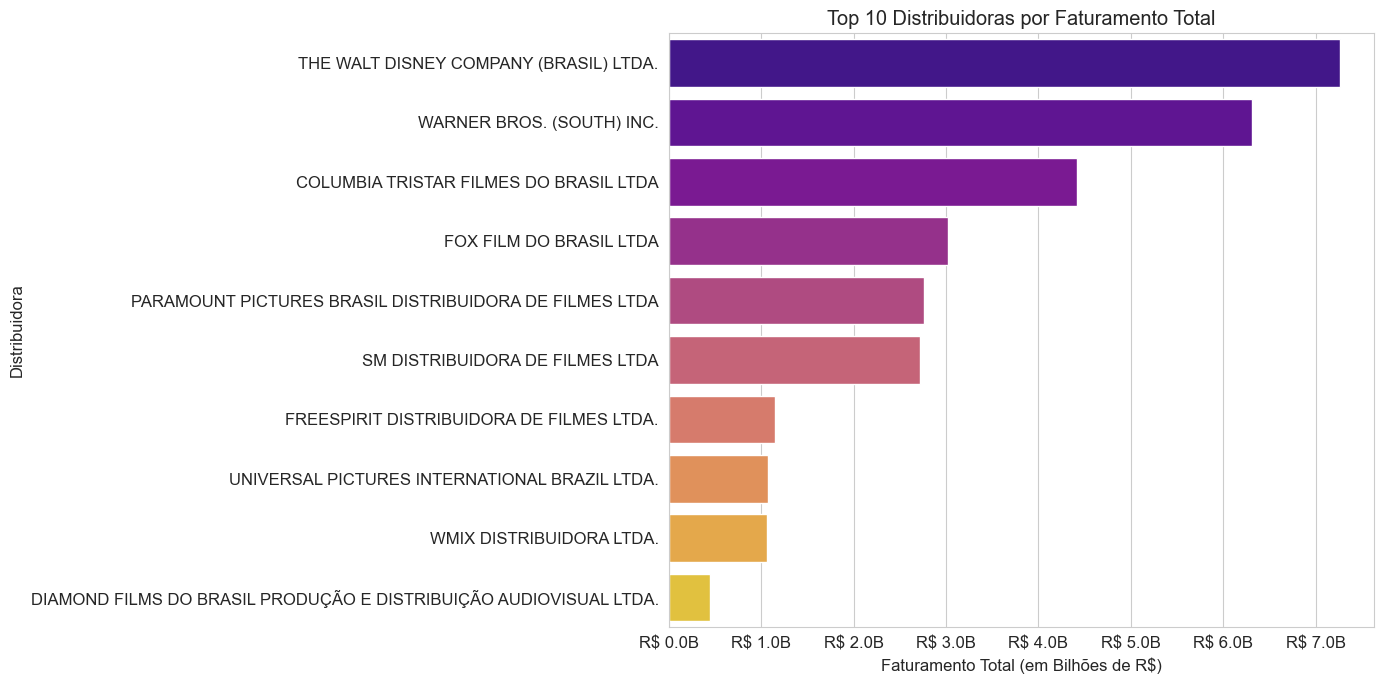

In [10]:
if df is not None:
    top_10_renda = df.groupby('RAZAO_SOCIAL_DISTRIBUIDORA')['RENDA_TOTAL'].sum().sort_values(ascending=False).head(10)
    
    print("\nTop 10 Distribuidoras por Faturamento Total:")
    display(top_10_renda.apply(lambda x: f"R$ {x:,.2f}"))
    
    # Gráfico de barras (código atualizado para remover o aviso)
    ax = sns.barplot(x=top_10_renda.values, y=top_10_renda.index, hue=top_10_renda.index, palette='plasma', legend=False)
    ax.set_title('Top 10 Distribuidoras por Faturamento Total')
    ax.set_xlabel('Faturamento Total (em Bilhões de R$)')
    ax.set_ylabel('Distribuidora')
    
    # Formatação do eixo X para melhor leitura
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e9:.1f}B')
    ax.xaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    plt.show()

Top 10 Filmes de Maior Bilheteria


Top 10 Filmes com Maior Bilheteria:


,TITULO_ORIGINAL,RENDA_TOTAL,RAZAO_SOCIAL_DISTRIBUIDORA,DATA_LANCAMENTO_OBRA
544,INSIDE OUT 2,4.444441e+08,THE WALT DISNEY COMPANY (BRASIL) LTDA.,2024-06-20
2422,AVENGERS: ENDGAME,3.386250e+08,THE WALT DISNEY COMPANY (BRASIL) LTDA.,2019-04-25
1619,SPIDER-MAN: NO WAY HOME,3.174329e+08,COLUMBIA TRISTAR FILMES DO BRASIL LTDA,2021-12-16
2332,THE LION KING,2.659040e+08,THE WALT DISNEY COMPANY (BRASIL) LTDA.,2019-07-18
1224,AVATAR: THE WAY OF WATER,2.413956e+08,THE WALT DISNEY COMPANY (BRASIL) LTDA.,2022-12-15
2909,AVENGERS: INFINITY WAR,2.377818e+08,THE WALT DISNEY COMPANY (BRASIL) LTDA.,2018-04-26
80,LILO & STITCH,2.128650e+08,THE WALT DISNEY COMPANY (BRASIL) LTDA.,2025-05-22
993,BARBIE,2.097708e+08,WARNER BROS. (SOUTH) INC.,2023-07-20
321,MOANA 2,1.777961e+08,THE WALT DISNEY COMPANY (BRASIL) LTDA.,2024-11-28
1502,DOCTOR STRANGE IN THE MULTIVERSE OF MADNESS,1.694304e+08,THE WALT DISNEY COMPANY (BRASIL) LTDA.,2022-05-05


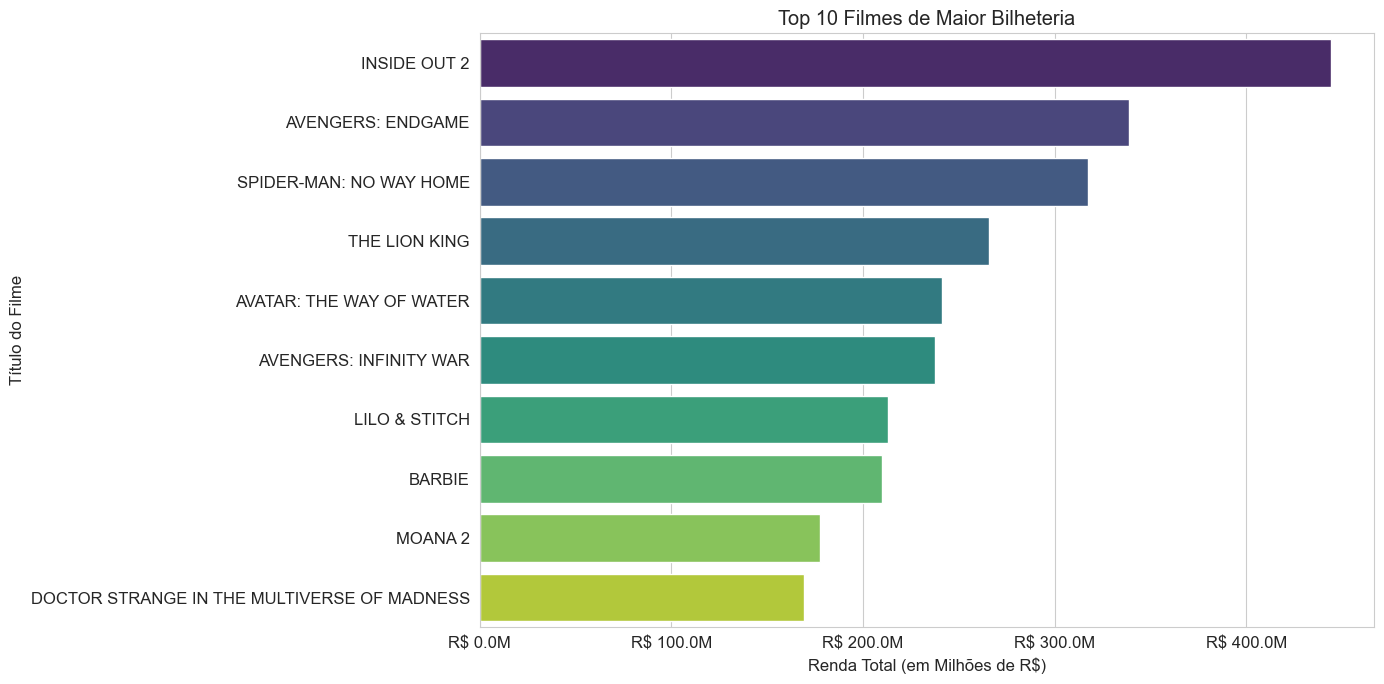

In [11]:
if df is not None:
    top_10_filmes_renda = df.sort_values(by='RENDA_TOTAL', ascending=False).head(10)
    
    print("\nTop 10 Filmes com Maior Bilheteria:")
    # Mostrando colunas relevantes
    display(top_10_filmes_renda[['TITULO_ORIGINAL', 'RENDA_TOTAL', 'RAZAO_SOCIAL_DISTRIBUIDORA', 'DATA_LANCAMENTO_OBRA']])

    # Gráfico de barras
    ax = sns.barplot(x='RENDA_TOTAL', y='TITULO_ORIGINAL', data=top_10_filmes_renda, hue='TITULO_ORIGINAL', palette='viridis', legend=False)
    ax.set_title('Top 10 Filmes de Maior Bilheteria')
    ax.set_xlabel('Renda Total (em Milhões de R$)')
    ax.set_ylabel('Título do Filme')

    # Formatação do eixo X para melhor leitura
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e6:.1f}M')
    ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()

Faturamento por País de Origem da Obra


Top 10 Países por Faturamento Total Gerado:


PAIS_OBRA
ESTADOS UNIDOS    R$ 25,356,912,141.57
BRASIL             R$ 3,492,272,027.90
CANADÁ               R$ 822,490,524.74
FRANÇA               R$ 426,052,211.32
CHINA                R$ 367,198,298.80
ALEMANHA             R$ 195,841,573.13
ESPANHA              R$ 173,769,461.71
REINO UNIDO          R$ 133,746,327.22
AUSTRÁLIA            R$ 125,773,647.18
JAPÃO                 R$ 98,127,800.65
Name: RENDA_TOTAL, dtype: object

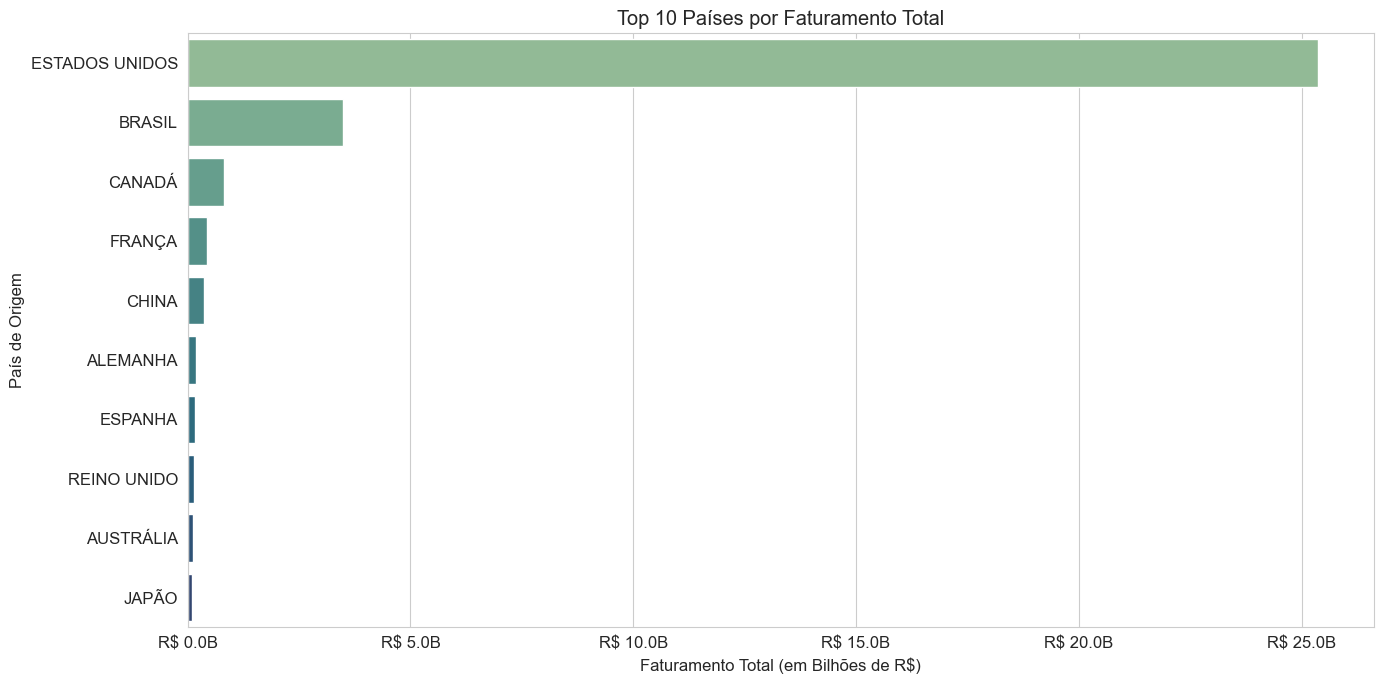

In [12]:
if df is not None:
    top_10_paises = df.groupby('PAIS_OBRA')['RENDA_TOTAL'].sum().sort_values(ascending=False).head(10)
    
    print("\nTop 10 Países por Faturamento Total Gerado:")
    display(top_10_paises.apply(lambda x: f"R$ {x:,.2f}"))

    # Gráfico de barras
    ax = sns.barplot(x=top_10_paises.values, y=top_10_paises.index, hue=top_10_paises.index, palette='crest', legend=False)
    ax.set_title('Top 10 Países por Faturamento Total')
    ax.set_xlabel('Faturamento Total (em Bilhões de R$)')
    ax.set_ylabel('País de Origem')
    
    # Formatação do eixo X
    formatter = FuncFormatter(lambda x, pos: f'R$ {x/1e9:.1f}B')
    ax.xaxis.set_major_formatter(formatter)
    
    plt.tight_layout()
    plt.show()

Desempenho por Gênero/Tipo de Obra


Faturamento Total por Tipo de Obra:


TIPO_OBRA
FICÇÃO                                R$ 25,641,950,424.05
ANIMAÇÃO                               R$ 5,754,063,388.69
VARIEDADES                               R$ 107,303,213.57
DOCUMENTÁRIO                              R$ 85,027,154.96
VÍDEOMUSICAL                              R$ 41,860,475.78
RELIGIOSA                                 R$ 24,497,202.20
NÃO CLASSIFICADA                             R$ 122,212.80
MANIFESTAÇÕES E EVENTOS ESPORTIVOS            R$ 35,217.00
JORNALÍSTICA                                  R$ 31,031.03
Name: RENDA_TOTAL, dtype: object

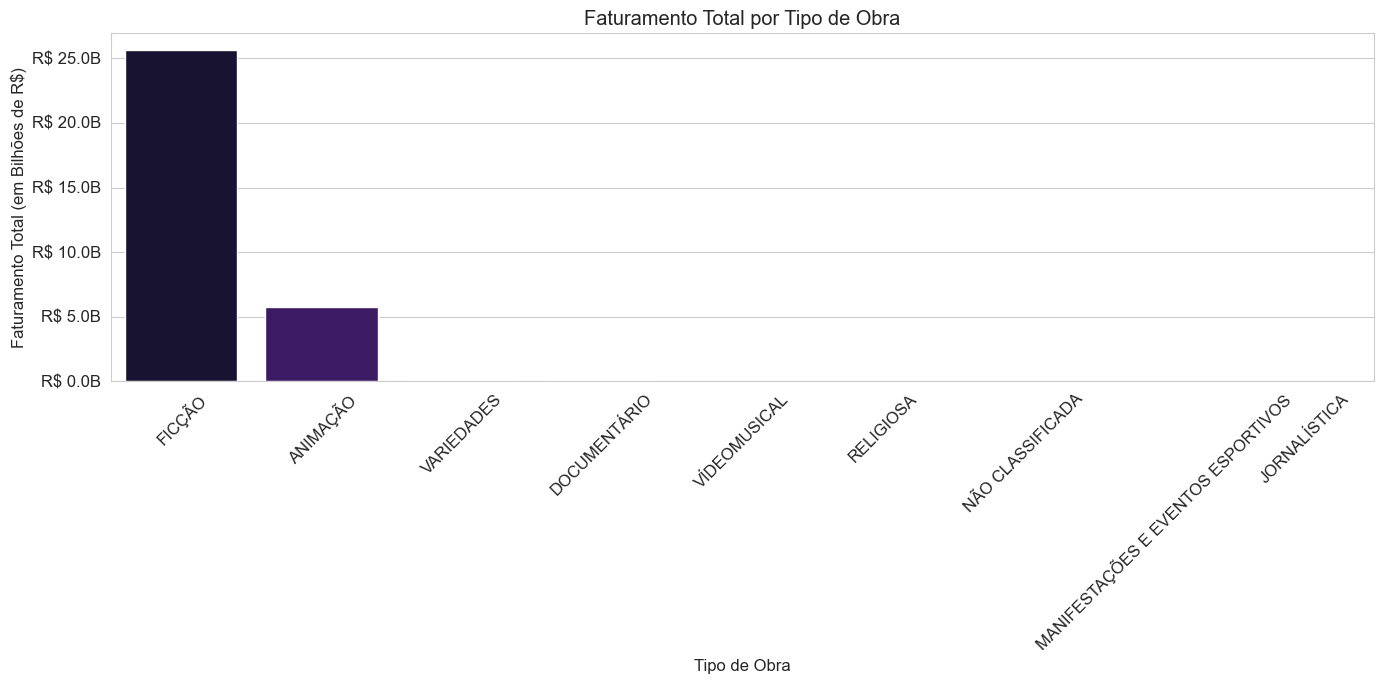

In [13]:
if df is not None:
    renda_por_tipo = df.groupby('TIPO_OBRA')['RENDA_TOTAL'].sum().sort_values(ascending=False)
    
    print("\nFaturamento Total por Tipo de Obra:")
    display(renda_por_tipo.apply(lambda x: f"R$ {x:,.2f}"))

    # Gráfico de barras
    ax = sns.barplot(x=renda_por_tipo.index, y=renda_por_tipo.values, hue=renda_por_tipo.index, palette='magma', legend=False)
    ax.set_title('Faturamento Total por Tipo de Obra')
    ax.set_xlabel('Tipo de Obra')
    ax.set_ylabel('Faturamento Total (em Bilhões de R$)')
    
    # Formatação do eixo Y
    formatter = FuncFormatter(lambda y, pos: f'R$ {y/1e9:.1f}B')
    ax.yaxis.set_major_formatter(formatter)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Relação entre Público e Renda

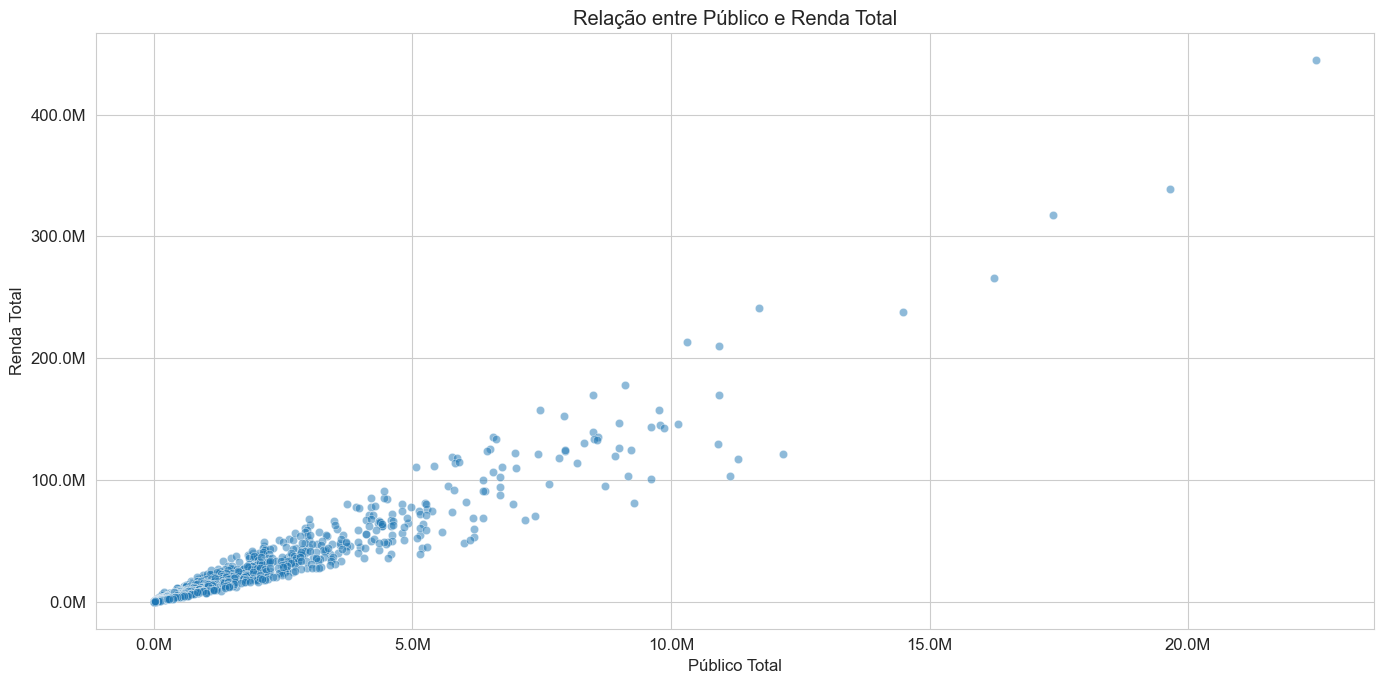

In [14]:
if df is not None:
    # Para uma melhor visualização, podemos filtrar filmes com renda e público muito baixos
    df_filtrado = df[(df['PUBLICO_TOTAL'] > 1000) & (df['RENDA_TOTAL'] > 10000)]

    ax = sns.scatterplot(data=df_filtrado, x='PUBLICO_TOTAL', y='RENDA_TOTAL', alpha=0.5)
    ax.set_title('Relação entre Público e Renda Total')
    ax.set_xlabel('Público Total')
    ax.set_ylabel('Renda Total')
    
    # Formatação dos eixos
    formatter_milhoes = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
    ax.xaxis.set_major_formatter(formatter_milhoes)
    ax.yaxis.set_major_formatter(formatter_milhoes)
    
    plt.tight_layout()
    plt.show()

Top 10 Filmes por Ticket Médio

C:\Users\alvea\AppData\Local\Temp\ipykernel_26300\3456312280.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


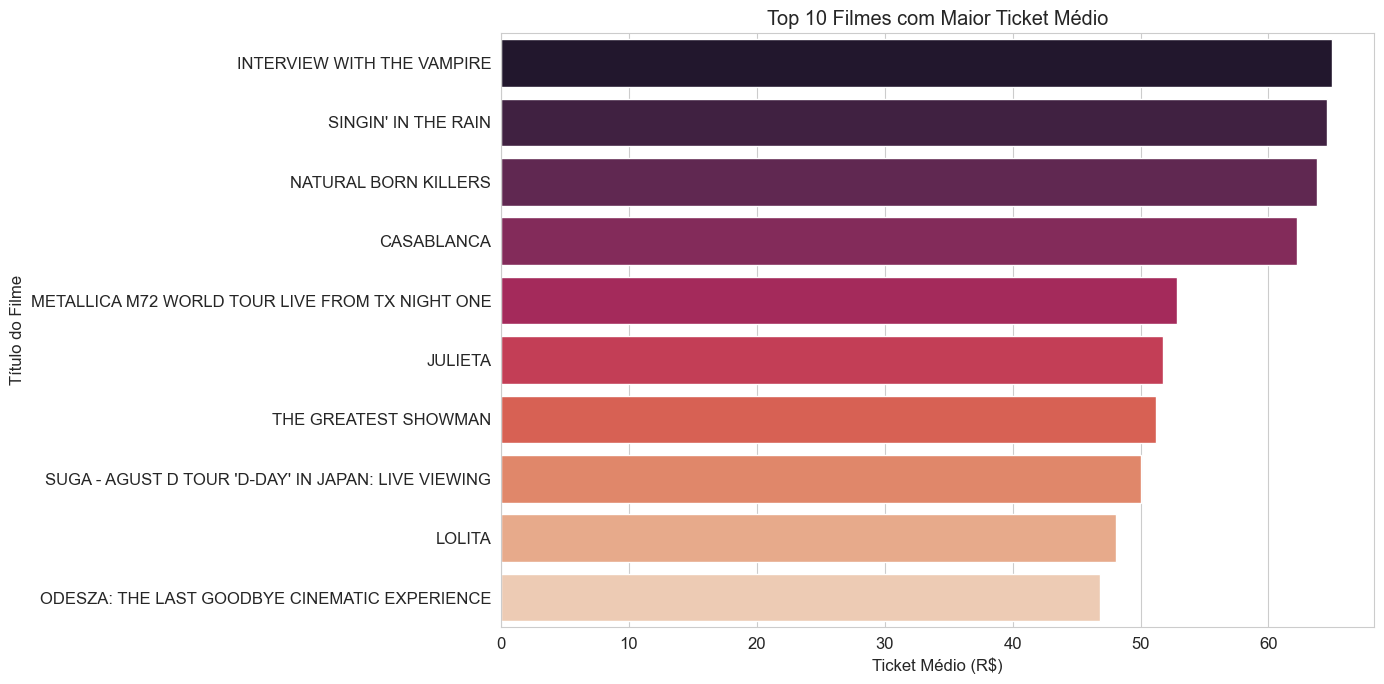

In [15]:
if df is not None:
    # Calculando o ticket médio
    df['ticket_medio'] = df.apply(
        lambda row: row['RENDA_TOTAL'] / row['PUBLICO_TOTAL'] if row['PUBLICO_TOTAL'] > 0 else 0, 
        axis=1
    )
    
    # Aplicando método IQR para identificar outliers
    Q1_ticket = df['ticket_medio'].quantile(0.25)
    Q3_ticket = df['ticket_medio'].quantile(0.75)
    IQR_ticket = Q3_ticket - Q1_ticket
    
    limite_superior_ticket = Q3_ticket + 1.5 * IQR_ticket
    
    # Identificando outliers altos (acima do limite superior)
    outliers_alto = df[df['ticket_medio'] > limite_superior_ticket]
    
    # Selecionando os top 10 outliers para visualização
    top_10_ticket = outliers_alto.nlargest(10, 'ticket_medio')
    
    # Gráfico de barras dos top 10 tickets médios
    ax = sns.barplot(data=top_10_ticket, y='TITULO_ORIGINAL', x='ticket_medio', 
                    hue='TITULO_ORIGINAL', palette='rocket', legend=False)
    ax.set_title('Top 10 Filmes com Maior Ticket Médio')
    ax.set_xlabel('Ticket Médio (R$)')
    ax.set_ylabel('Título do Filme')
    
    # Truncar títulos longos para melhor visualização
    labels = [label.get_text()[:50] + '...' if len(label.get_text()) > 50 else label.get_text() 
             for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)
    
    plt.tight_layout()
    plt.show()

Top 10 Filmes com Menor Ticket Médio

C:\Users\alvea\AppData\Local\Temp\ipykernel_26300\3251627081.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


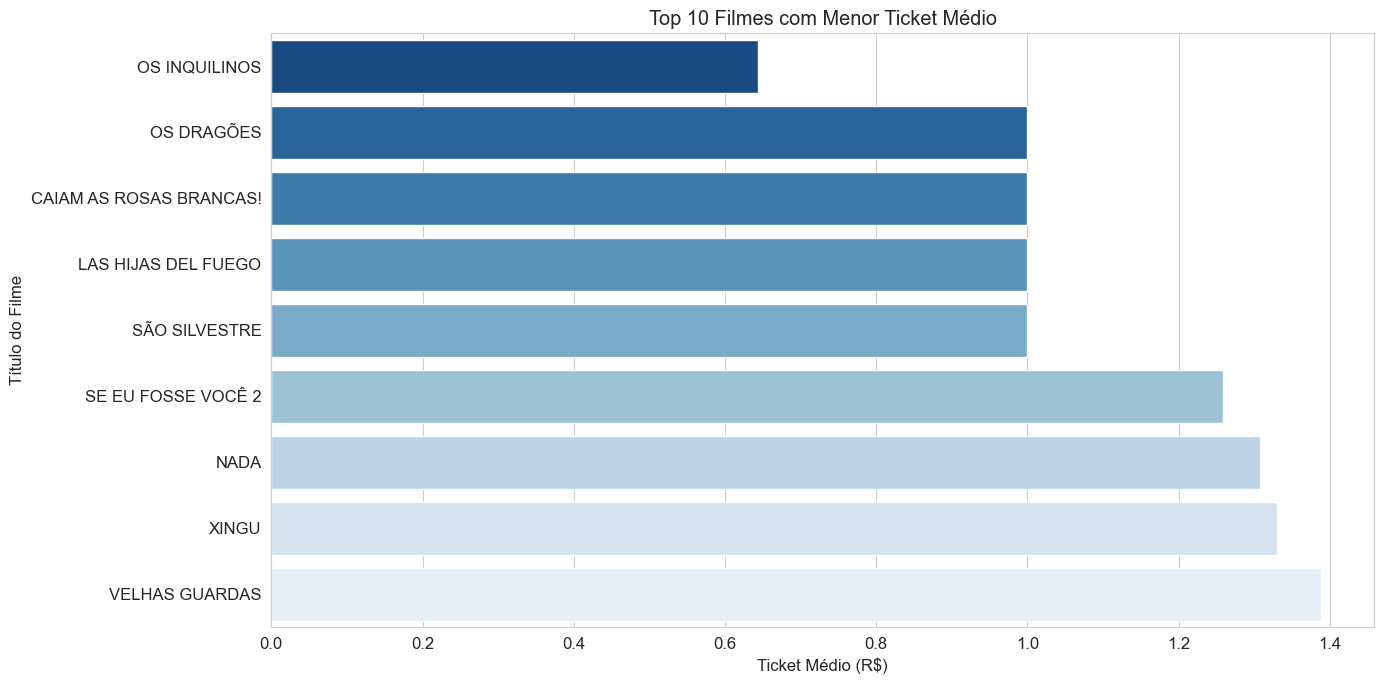

In [16]:
if df is not None:
    # Usando os dados já calculados de ticket médio da célula anterior
    # Filtrar apenas filmes com público maior que 0 para evitar divisões por zero
    df_valido = df[df['PUBLICO_TOTAL'] > 0].copy()
    
    # Aplicando método IQR para identificar outliers baixos
    Q1_ticket = df_valido['ticket_medio'].quantile(0.25)
    IQR_ticket = df_valido['ticket_medio'].quantile(0.75) - Q1_ticket
    
    limite_inferior_ticket = Q1_ticket - 1.5 * IQR_ticket
    
    # Identificando outliers baixos (abaixo do limite inferior)
    outliers_baixo = df_valido[df_valido['ticket_medio'] < limite_inferior_ticket]
    
    # Se não há outliers baixos suficientes, pegar os 10 menores valores
    if len(outliers_baixo) < 10:
        top_10_menores = df_valido.nsmallest(10, 'ticket_medio')
    else:
        top_10_menores = outliers_baixo.nsmallest(10, 'ticket_medio')
    
    # Gráfico de barras dos top 10 menores tickets médios
    ax = sns.barplot(data=top_10_menores, y='TITULO_ORIGINAL', x='ticket_medio', 
                    hue='TITULO_ORIGINAL', palette='Blues_r', legend=False)
    ax.set_title('Top 10 Filmes com Menor Ticket Médio')
    ax.set_xlabel('Ticket Médio (R$)')
    ax.set_ylabel('Título do Filme')
    
    # Truncar títulos longos para melhor visualização
    labels = [label.get_text()[:50] + '...' if len(label.get_text()) > 50 else label.get_text() 
             for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)
    
    plt.tight_layout()
    plt.show()

Distribuição Completa de Tickets Médios